## Import Libraries

In [2]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import cv2
import numpy as np
from skimage.feature import hog
import requests
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [3]:
df = pd.read_csv("travel_dataset_clean_final.csv")

## Feture Extraction

In [4]:
Total_features = []

In [5]:
df["image_url"].isna().sum()

np.int64(0)

In [6]:
images_URL = df["image_url"]

In [ ]:
import os
import requests
from pathlib import Path

os.makedirs('images', exist_ok=True)

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
downloaded_paths = []

for idx, url in enumerate(images_URL):
    try:
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
        filename = f"images/image_{idx}.jpg"
        with open(filename, 'wb') as f:
            f.write(r.content)
        
        downloaded_paths.append(filename)
        print(f"Downloaded {idx+1}/{len(images_URL)}")
        
    except Exception as e:
        print(f"Failed {idx+1}: {e}")
        downloaded_paths.append(None)

df['local_image_path'] = downloaded_paths
df = df[df['local_image_path'].notna()] 

df.to_csv('data_with_local_images.csv', index=False)

In [ ]:
df_clean = df[df['local_image_path'].notna()].copy()

print(f"Original dataset: {len(df)} images")
print(f"After removing failures: {len(df_clean)} images")
print(f"Removed: {len(df) - len(df_clean)} images ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")
print("\nWeather distribution:")
print(df_clean['weather'].value_counts())

print("\nMood distribution:")
print(df_clean['mood'].value_counts())

df_clean.to_csv('dataset_clean.csv', index=False)

Original dataset: 864 images
After removing failures: 864 images
Removed: 0 images (0.0%)

Weather distribution:
weather
Sunny        502
Cloudy       180
Not Clear     86
Snowy         78
Rainy         18
Name: count, dtype: int64

Mood distribution:
mood
Excited     274
Romantic    187
Happy       181
Curious     174
Calm         48
Name: count, dtype: int64


In [3]:
df = pd.read_csv("dataset_clean.csv")

### Color Histogram (HSV)

In [ ]:
def safe_imread(path, flags=cv2.IMREAD_COLOR):
    data = np.fromfile(path, dtype=np.uint8)   
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)


In [6]:
Total_features = []
valid_idx = []

for idx, img_path in enumerate(df['local_image_path']):
    if not os.path.exists(img_path):
        faild_path += 1
        continue

    img = safe_imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        continue

    features = []
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)

    for i in range(3):
        hist = cv2.calcHist([img_hsv], [i], None, [16], [0, 256])
        features.extend(hist.flatten())

    features.extend(np.mean(img_resized, axis=(0, 1)))
    features.extend(np.std(img_resized, axis=(0, 1)))

    Total_features.append(np.array(features))
    valid_idx.append(idx)

Total_features = np.array(Total_features)
df_valid = df.iloc[valid_idx].reset_index(drop=True)


In [ ]:
df_valid.shape

(803, 9)

### KNN for Weather

In [20]:
X = Total_features
Y = df_valid["weather"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)


### euclidean

In [22]:
knn_k1 = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn_k1.fit(X_train, y_train)

y_pred_k1 = knn_k1.predict(X_test)

accuracy_k1 = accuracy_score(y_test, y_pred_k1)

cm1 = confusion_matrix(
    y_test,
    y_pred_k1,
    labels=np.unique(y_test)
)
report1 = classification_report(y_test, y_pred_k1, digits=4)


In [29]:
print("KNN k=1 Accuracy:", accuracy_k1)
print("Classification Report:\n", report1)

KNN k=1 Accuracy: 0.475
Classification Report:
               precision    recall  f1-score   support

      Cloudy     0.2353    0.2353    0.2353        34
   Not Clear     0.0588    0.0909    0.0714        11
       Rainy     0.2857    0.5000    0.3636         4
       Snowy     0.3571    0.2941    0.3226        17
       Sunny     0.6818    0.6383    0.6593        94

    accuracy                         0.4750       160
   macro avg     0.3238    0.3517    0.3305       160
weighted avg     0.4997    0.4750    0.4856       160



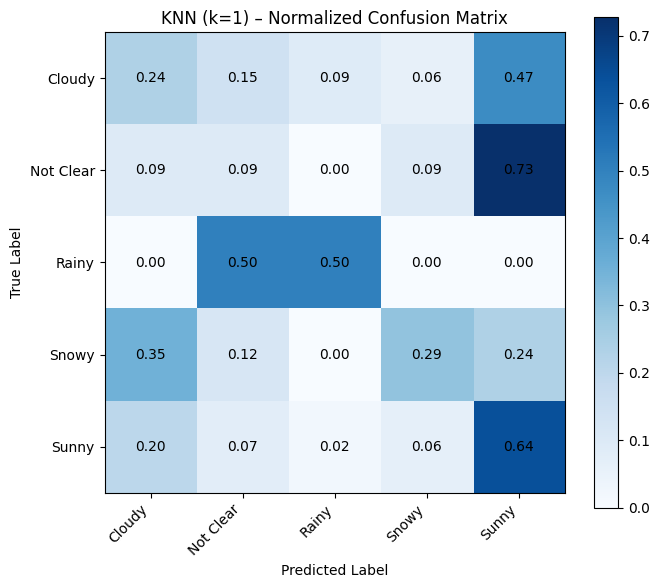

In [30]:
cm_norm = cm1.astype("float") / cm1.sum(axis=1, keepdims=True)
classes = np.unique(y_test)

plt.figure(figsize=(7, 6))
plt.imshow(cm_norm, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN (k=1) – Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
knn_k3 = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_k3.fit(X_train, y_train)
y_pred_k3 = knn_k3.predict(X_test)

accuracy_k3 = accuracy_score(y_test, y_pred_k3)
cm3 = confusion_matrix(y_test, y_pred_k3, labels=np.unique(y_test))
report3 = classification_report(y_test, y_pred_k3, digits=4)

c:\Users\Microsoft\.conda\envs\cvp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Microsoft\.conda\envs\cvp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Microsoft\.conda\envs\cvp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [33]:
print(f"Accuracy k3: {accuracy_k3:.4f}")
print("Classification Report:\n", report3)

Accuracy k3: 0.5375
Classification Report:
               precision    recall  f1-score   support

      Cloudy     0.2692    0.4118    0.3256        34
   Not Clear     0.1000    0.0909    0.0952        11
       Rainy     0.6667    0.5000    0.5714         4
       Snowy     0.0000    0.0000    0.0000        17
       Sunny     0.7263    0.7340    0.7302        94

    accuracy                         0.5375       160
   macro avg     0.3524    0.3473    0.3445       160
weighted avg     0.5075    0.5375    0.5190       160



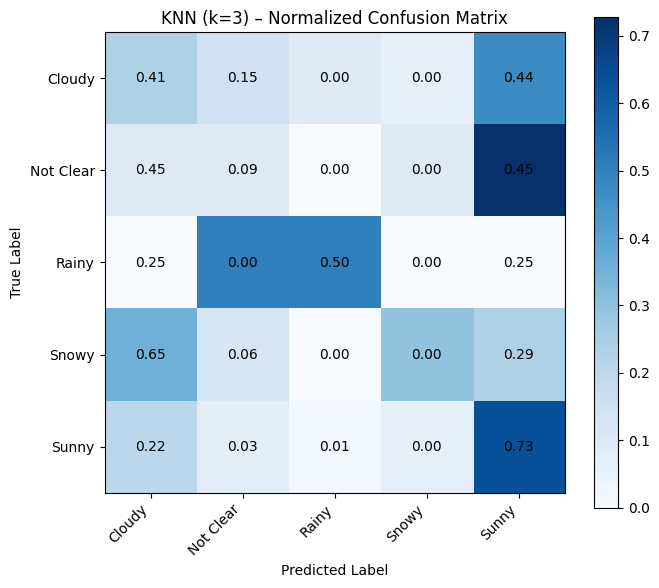

In [32]:
cm_norm3 = cm3.astype("float") / cm3.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
plt.imshow(cm_norm, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)

for i in range(cm_norm3.shape[0]):
    for j in range(cm_norm3.shape[1]):
        plt.text(j, i, f"{cm_norm3[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN (k=3) – Normalized Confusion Matrix")
plt.tight_layout()
plt.show()